# 05 — Static user-equilibrium traffic assignment

Traffic assignment loads the OD matrix onto the network such that (at equilibrium)
no driver can reduce their travel time by switching routes — Wardrop's first principle.
AequilibraE provides state-of-practice algorithms (MSA, Frank-Wolfe, CFW, **BFW**) with
BPR-style volume-delay functions:

$t = t_0 \left(1 + \alpha \left(\frac{V}{C}\right)^{\beta}\right)$

We assign Sioux Falls demand, inspect convergence, save results, and map congestion.


In [1]:
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

from aequilibrae.utils.create_example import create_example
from aequilibrae.paths import TrafficAssignment, TrafficClass

fldr = str(Path(gettempdir()) / uuid4().hex)
project = create_example(fldr, "sioux_falls")

project.network.build_graphs()
graph = project.network.graphs["c"]
graph.set_graph("free_flow_time")
graph.set_skimming(["free_flow_time", "distance"])
graph.set_blocked_centroid_flows(False)

demand = project.matrices.get_matrix("demand_omx")
demand.computational_view(["matrix"])

C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)
C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)
C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  build_compressed_graph(self, remove_dead_ends)
C:\Users\Riz\Desktop\AequilibraE\aequilibrae\aequilibrae\paths\graph.py:218: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

In [2]:
assigclass = TrafficClass(name="car", graph=graph, matrix=demand)

assig = TrafficAssignment()
assig.add_class(assigclass)
assig.set_vdf("BPR")
assig.set_vdf_parameters({"alpha": "b", "beta": "power"})   # per-link fields in this model
assig.set_capacity_field("capacity")
assig.set_time_field("free_flow_time")
assig.set_algorithm("bfw")
assig.max_iter = 500
assig.rgap_target = 0.0001

assig.execute()

car                                               :   0%|          | 0/24 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/500 [00:00<?, ?it/s]

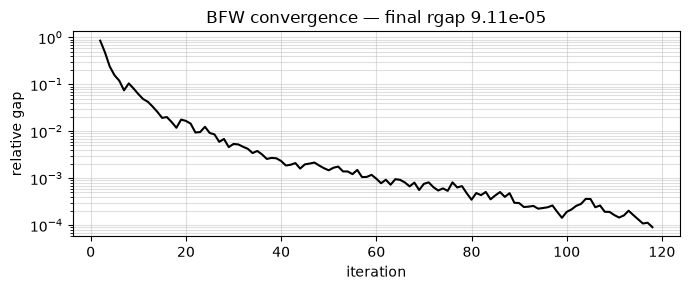

In [3]:
# Convergence: relative gap per iteration
import matplotlib.pyplot as plt

report = assig.report()
plt.figure(figsize=(7, 3))
plt.plot(report.iteration, report.rgap, "k-")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.4)
plt.xlabel("iteration"); plt.ylabel("relative gap")
plt.title(f"BFW convergence — final rgap {report.rgap.iloc[-1]:.2e}")
plt.tight_layout()

In [4]:
results = assig.results()
results[["matrix_ab", "matrix_ba", "matrix_tot", "VOC_max"]].describe().T

,count,mean,std,min,25%,50%,75%,max
matrix_ab,76.0,11552.907262,4736.192582,4490.833243,8366.570100,9976.951810,15358.934827,23196.870201
matrix_ba,76.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
matrix_tot,76.0,11552.907262,4736.192582,4490.833243,8366.570100,9976.951810,15358.934827,23196.870201
VOC_max,76.0,1.465741,0.577192,0.173390,1.076281,1.601276,1.779009,2.556272


In [5]:
# Persist link flows and skims into the project databases
assig.save_results("base_year_assignment")
assig.save_skims("base_year_skims", which_ones="all", format="omx")

## Mapping congestion

We join the assignment results back to the link geometry and color links by their
volume/capacity ratio using JupyterGIS' graduated symbology
(`field(...).colormap(...)`).


In [6]:
# JupyterGIS map helper ------------------------------------------------------
# GISDocument is JupyterGIS' notebook API: it builds a live, QGIS-like map
# document rendered directly in JupyterLab. Layers added from GeoDataFrames
# are converted to GeoJSON on the fly.
import json
from jupytergis import GISDocument

OSM_TILES = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"

def new_map(gdf_for_extent=None, zoom=12):
    """Create a GISDocument centred on a layer, with an OpenStreetMap basemap."""
    kwargs = {}
    if gdf_for_extent is not None:
        b = gdf_for_extent.total_bounds  # (minx, miny, maxx, maxy)
        kwargs = {"longitude": (b[0] + b[2]) / 2, "latitude": (b[1] + b[3]) / 2, "zoom": zoom}
    doc = GISDocument(**kwargs)
    doc.add_raster_layer(OSM_TILES, name="OpenStreetMap", attribution="(C) OpenStreetMap contributors", opacity=0.6)
    return doc

def add_gdf(doc, gdf, name, **kwargs):
    """Add a GeoDataFrame to the map as a GeoJSON layer."""
    return doc.add_geojson_layer(data=json.loads(gdf.to_json()), name=name, **kwargs)

In [7]:
from jupytergis_lab.notebook.symbology import constant, field

links = project.network.links.data
loaded = links.merge(results.reset_index(), on="link_id")
loaded["voc"] = loaded["VOC_max"].round(3)

doc = new_map(loaded, zoom=12)
vmax = float(loaded["voc"].max())
add_gdf(
    doc, loaded[["link_id", "voc", "matrix_tot", "geometry"]], "V/C ratio",
    symbology=[[field("voc").colormap("RdYlGn_r", domain=(0.0, vmax)).encoding("stroke")]],
)
doc

C:\Users\Riz\AppData\Local\Temp\ipykernel_24400\1823397229.py:16: UserWarning: The JupyterGIS Python API is better experienced in the xeus-python kernel which supports awaiting comm messages
  doc = GISDocument(**kwargs)


In [8]:
project.close()

---
**Next:** [06 — Route choice](06_route_choice.ipynb): beyond a single shortest path —
generating realistic route sets and assigning with path-size logit.
